Adjusted Rand Index Scores:
KMeans: 0.011
DBSCAN: 0.116
Isolation Forest: -0.023


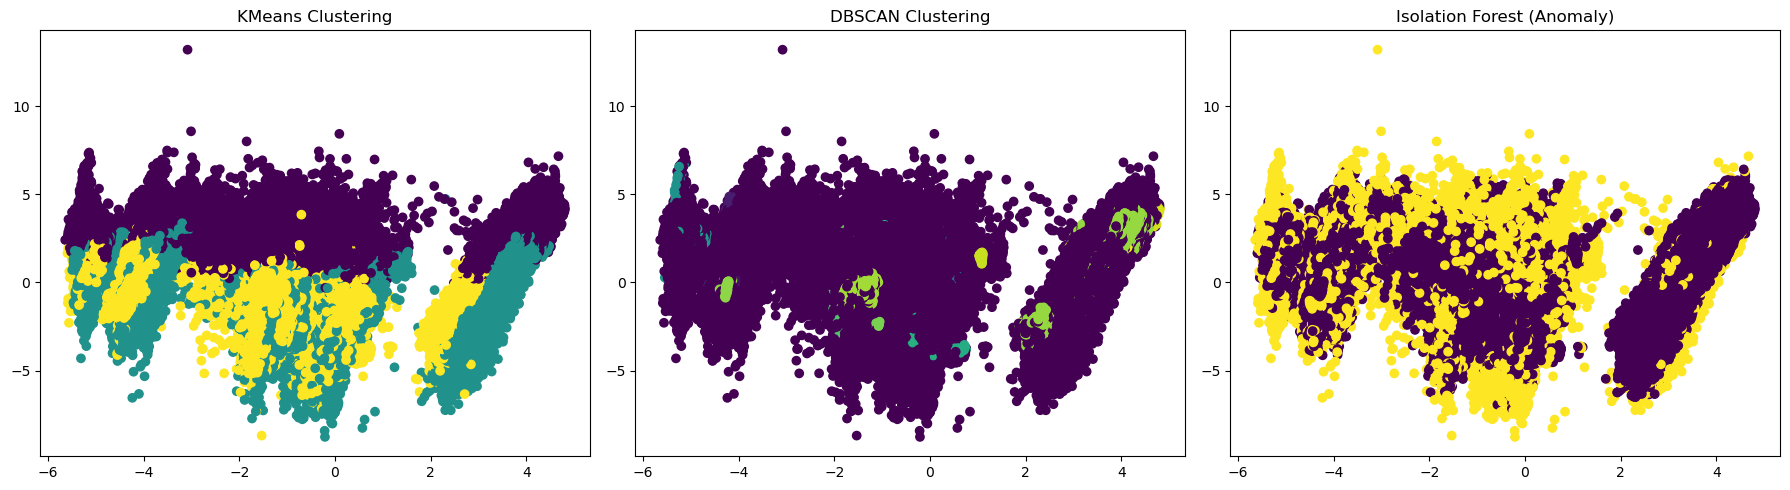

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import adjusted_rand_score, confusion_matrix



# Load both CSVs
squat_df = pd.read_csv("merged_data_squat.csv")
squat_df["exercise"] = "squat"

rdl_df = pd.read_csv("merged_data_rdl.csv")
rdl_df["exercise"] = "rdl"

# Combine both datasets
df = pd.concat([squat_df, rdl_df], ignore_index=True)

# Separate features and labels
# Remove all non-feature columns
X = df.drop(columns=["frame", "label", "exercise"])
y_true = df["label"]


# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Optional: Reduce dimensions for visualization
pca = PCA(n_components=15)
X_pca = pca.fit_transform(X_scaled)

# ---------------------------
# 1. KMeans Clustering
# ---------------------------
kmeans = KMeans(n_clusters=3, random_state=0)
kmeans_labels = kmeans.fit_predict(X_scaled)
ari_kmeans = adjusted_rand_score(y_true, kmeans_labels)

# ---------------------------
# 2. DBSCAN
# ---------------------------
dbscan = DBSCAN(eps=2, min_samples=10)
dbscan_labels = dbscan.fit_predict(X_scaled)
ari_dbscan = adjusted_rand_score(y_true, dbscan_labels)

# ---------------------------
# 3. Isolation Forest
# ---------------------------
iso_forest = IsolationForest(n_estimators=100, contamination=0.1, random_state=0)
iso_labels = iso_forest.fit_predict(X_scaled)
# Convert IF output: 1 = normal, -1 = anomaly
# We'll assume label 1 = correct (normal), others = anomaly
iso_mapped = np.where(iso_labels == 1, 0, 1)
ari_iso = adjusted_rand_score(y_true, iso_mapped)

# ---------------------------
# Report Results
# ---------------------------
print("Adjusted Rand Index Scores:")
print(f"KMeans: {ari_kmeans:.3f}")
print(f"DBSCAN: {ari_dbscan:.3f}")
print(f"Isolation Forest: {ari_iso:.3f}")

# ---------------------------
# Visualize PCA space
# ---------------------------
fig, axs = plt.subplots(1, 3, figsize=(18, 5))
axs[0].scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='viridis')
axs[0].set_title("KMeans Clustering")

axs[1].scatter(X_pca[:, 0], X_pca[:, 1], c=dbscan_labels, cmap='viridis')
axs[1].set_title("DBSCAN Clustering")

axs[2].scatter(X_pca[:, 0], X_pca[:, 1], c=iso_mapped, cmap='viridis')
axs[2].set_title("Isolation Forest (Anomaly)")

plt.tight_layout()
plt.show()


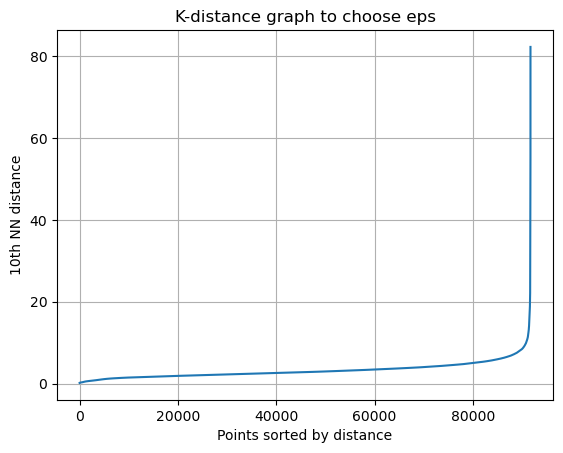

In [7]:
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import numpy as np

# Find the k-nearest neighbor distances
neighbors = NearestNeighbors(n_neighbors=10)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

# Sort distances to find knee
distances = np.sort(distances[:, 9])  # 9 = 10th nearest neighbor
plt.plot(distances)
plt.title("K-distance graph to choose eps")
plt.ylabel("10th NN distance")
plt.xlabel("Points sorted by distance")
plt.grid(True)
plt.show()


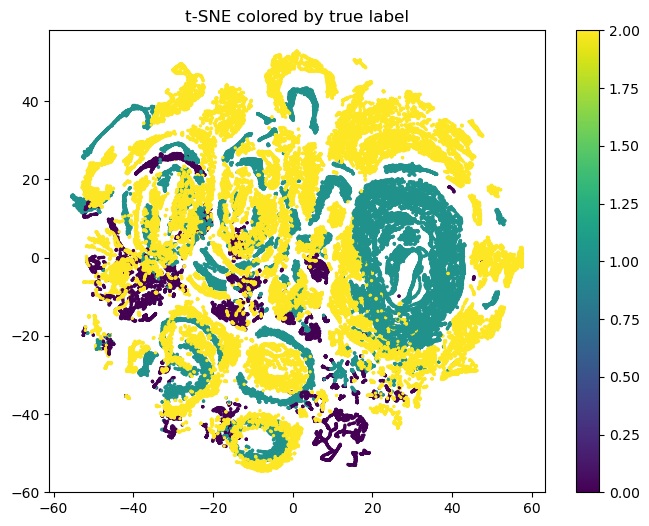

In [10]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_true, cmap='viridis', s=2)
plt.title("t-SNE colored by true label")
plt.colorbar()
plt.show()



In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd

# ================================
# Step 1: Prepare data
# ================================
# Assume df already loaded and cleaned:
# df = pd.concat([squat_df, rdl_df])
X = df.drop(columns=["frame", "label", "exercise"])
y_true = df["label"].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_tensor = torch.tensor(X_scaled, dtype=torch.float32)

# ================================
# Step 2: Define Autoencoder
# ================================
class Autoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim=8):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, input_dim)
        )

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z), z

input_dim = X_tensor.shape[1]
model = Autoencoder(input_dim=input_dim, latent_dim=8)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# ================================
# Step 3: Train Autoencoder
# ================================
model.train()
n_epochs = 50
batch_size = 512

for epoch in range(n_epochs):
    permutation = torch.randperm(X_tensor.size()[0])
    losses = []
    for i in range(0, X_tensor.size()[0], batch_size):
        indices = permutation[i:i + batch_size]
        batch = X_tensor[indices]
        optimizer.zero_grad()
        output, _ = model(batch)
        loss = criterion(output, batch)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}/{n_epochs}, Loss: {np.mean(losses):.6f}")

# ================================
# Step 4: Extract Latent Vectors
# ================================
model.eval()
with torch.no_grad():
    _, X_latent = model(X_tensor)

X_latent_np = X_latent.numpy()

# ================================
# Step 5: KMeans Clustering
# ================================
kmeans = KMeans(n_clusters=3, random_state=0)
kmeans_labels = kmeans.fit_predict(X_latent_np)
ari = adjusted_rand_score(y_true, kmeans_labels)

print(f"\nAutoencoder + KMeans ARI: {ari:.3f}")


Epoch 10/50, Loss: 0.274010
Epoch 20/50, Loss: 0.249848
Epoch 30/50, Loss: 0.238374
Epoch 40/50, Loss: 0.228685
Epoch 50/50, Loss: 0.222416

Autoencoder + KMeans ARI: 0.023


In [15]:
!pip install hdbscan


Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 28.8 MB/s eta 0:00:0000:0100:01


In [17]:
import hdbscan
from sklearn.metrics import adjusted_rand_score

# Run HDBSCAN on the 8D latent space
clusterer = hdbscan.HDBSCAN(min_cluster_size=50)
hdb_labels = clusterer.fit_predict(X_latent_np)

# Evaluate
ari_hdb = adjusted_rand_score(y_true, hdb_labels)
print(f"HDBSCAN on latent space ARI: {ari_hdb:.3f}")
print(f"Number of clusters: {len(set(hdb_labels)) - (1 if -1 in hdb_labels else 0)}")
print(f"Noise points: {(hdb_labels == -1).sum()}")


/home/jupyter-karla/.local/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/jupyter-karla/.local/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


HDBSCAN on latent space ARI: 0.043
Number of clusters: 15
Noise points: 22336


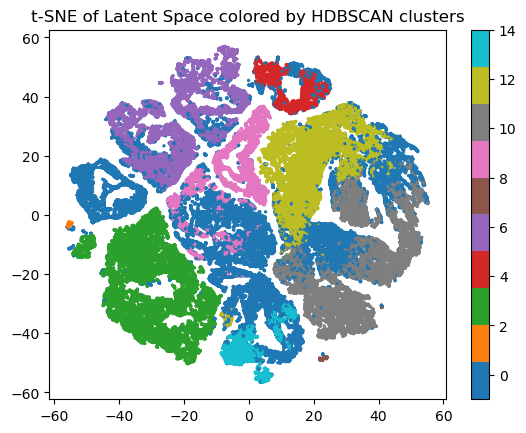

In [18]:
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=hdb_labels, cmap='tab10', s=2)
plt.title("t-SNE of Latent Space colored by HDBSCAN clusters")
plt.colorbar()
plt.show()


In [27]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import adjusted_rand_score
import hdbscan
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns

# Load both CSVs
squat_df = pd.read_csv("merged_data_squat.csv")
squat_df["exercise"] = "squat"

#rdl_df = pd.read_csv("merged_data_rdl.csv")
#rdl_df["exercise"] = "rdl"

# Combine both datasets
df = pd.concat([squat_df], ignore_index=True)

# Step 1: Segment into sliding windows
def segment_data(X, y, window_size=200, step=50):
    X_win, y_win = [], []
    for i in range(0, len(X) - window_size, step):
        X_seg = X[i:i+window_size]
        label = np.bincount(y[i:i+window_size]).argmax()  # majority label
        X_win.append(X_seg.flatten())  # flatten time x features to 1D
        y_win.append(label)
    return np.array(X_win), np.array(y_win)

# Extract features and labels
X_raw = df.drop(columns=["frame", "label", "exercise"]).values
y_raw = df["label"].values

# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# Window the data
X_windows, y_windows = segment_data(X_scaled, y_raw, window_size=50, step=25)

# Step 2: Autoencoder
class Autoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim=16):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, input_dim)
        )

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z), z

input_dim = X_windows.shape[1]
model = Autoencoder(input_dim=input_dim, latent_dim=16)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

X_tensor = torch.tensor(X_windows, dtype=torch.float32)
model.train()
for epoch in range(30):
    permutation = torch.randperm(X_tensor.size(0))
    for i in range(0, X_tensor.size(0), 256):
        indices = permutation[i:i+256]
        batch = X_tensor[indices]
        optimizer.zero_grad()
        output, _ = model(batch)
        loss = criterion(output, batch)
        loss.backward()
        optimizer.step()

# Extract latent features
model.eval()
with torch.no_grad():
    _, X_latent = model(X_tensor)
X_latent_np = X_latent.numpy()

# Step 3: t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_latent_np)

# Step 4: HDBSCAN clustering
clusterer = hdbscan.HDBSCAN(min_cluster_size=30)
hdb_labels = clusterer.fit_predict(X_latent_np)
ari = adjusted_rand_score(y_windows, hdb_labels)

# Prepare for export
tsne_df = pd.DataFrame({
    "tsne_1": X_tsne[:, 0],
    "tsne_2": X_tsne[:, 1],
    "label": y_windows,
    "cluster": hdb_labels
})

tsne_df.to_csv("tsne_hdbscan_results.csv", index=False)
print("Saved results to tsne_hdbscan_results.csv")



Saved results to tsne_hdbscan_results.csv


/home/jupyter-karla/.local/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/jupyter-karla/.local/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


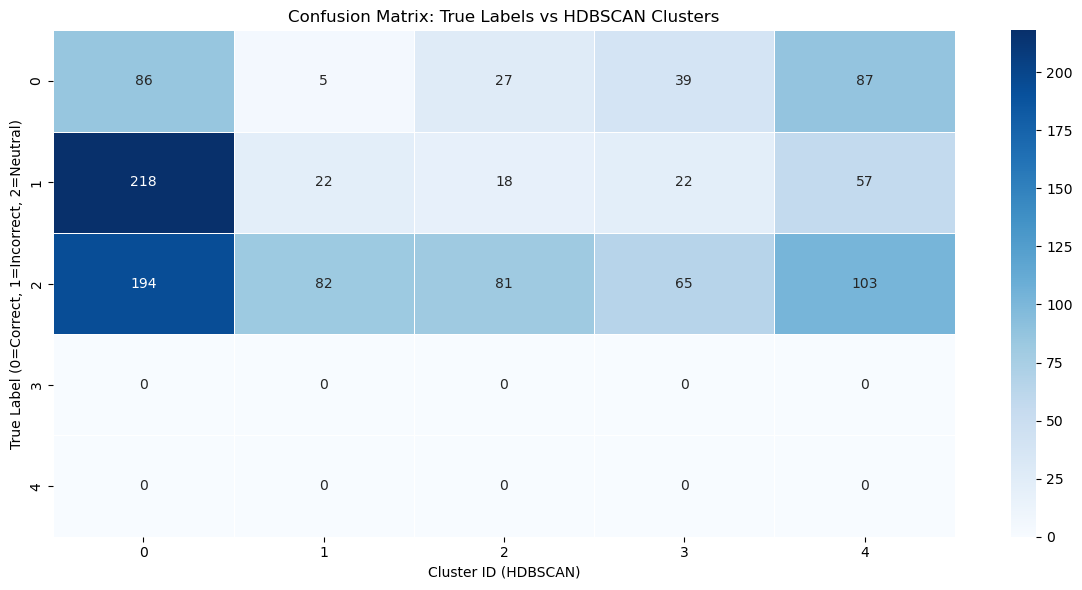

In [28]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure valid entries only (exclude HDBSCAN noise points)
valid_idx = hdb_labels != -1
true_valid = y_windows[valid_idx]
cluster_valid = hdb_labels[valid_idx]

# Confusion matrix: true label vs cluster
conf_mat = confusion_matrix(true_valid, cluster_valid)

# Plot
plt.figure(figsize=(12, 6))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap="Blues", linewidths=0.5, cbar=True)
plt.title("Confusion Matrix: True Labels vs HDBSCAN Clusters")
plt.xlabel("Cluster ID (HDBSCAN)")
plt.ylabel("True Label (0=Correct, 1=Incorrect, 2=Neutral)")
plt.tight_layout()
plt.show()


2025-07-24 13:06:09.969980: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-07-24 13:06:09.970069: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-07-24 13:06:10.033496: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-07-24 13:06:10.095040: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-07-24 13:06:11.034335: W tensorflow/compiler/tf2

Epoch 1/30


2025-07-24 13:06:14.452543: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8902
2025-07-24 13:06:14.624301: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2025-07-24 13:06:15.601768: I external/local_xla/xla/service/service.cc:168] XLA service 0x71e48430f540 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-07-24 13:06:15.601796: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce RTX 3080, Compute Capability 8.6
2025-07-24 13:06:15.601802: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (1): NVIDIA GeForce RTX 3080, Compute Capability 8.6
2025-07-24 13:06:15.611503: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1753355175.716929  913365 device_comp

23/23 [==============================] - 5s 53ms/step - loss: 0.9236 - accuracy: 0.4945 - val_loss: 0.8659 - val_accuracy: 0.5217
Epoch 2/30
23/23 [==============================] - 0s 13ms/step - loss: 0.7836 - accuracy: 0.6107 - val_loss: 0.3854 - val_accuracy: 0.8913
Epoch 3/30
23/23 [==============================] - 0s 13ms/step - loss: 0.7927 - accuracy: 0.6639 - val_loss: 0.6877 - val_accuracy: 0.7120
Epoch 4/30
23/23 [==============================] - 0s 13ms/step - loss: 0.5090 - accuracy: 0.8292 - val_loss: 0.3570 - val_accuracy: 0.8587
Epoch 5/30
23/23 [==============================] - 0s 13ms/step - loss: 0.4745 - accuracy: 0.8128 - val_loss: 0.3062 - val_accuracy: 0.9130
Epoch 6/30
23/23 [==============================] - 0s 12ms/step - loss: 0.3183 - accuracy: 0.8962 - val_loss: 0.2024 - val_accuracy: 0.9348
Epoch 7/30
23/23 [==============================] - 0s 13ms/step - loss: 0.2516 - accuracy: 0.9249 - val_loss: 0.2149 - val_accuracy: 0.9457
Epoch 8/30
23/23 [======

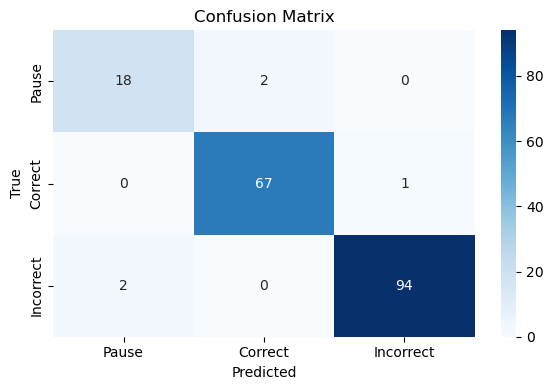

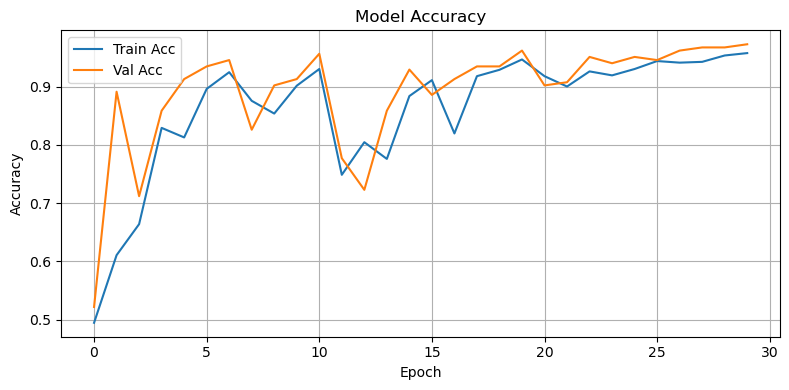

6/6 [==============================] - 0s 3ms/step


/tmp/ipykernel_913126/978801924.py:133: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sensor_names, y=accuracies, palette="viridis")


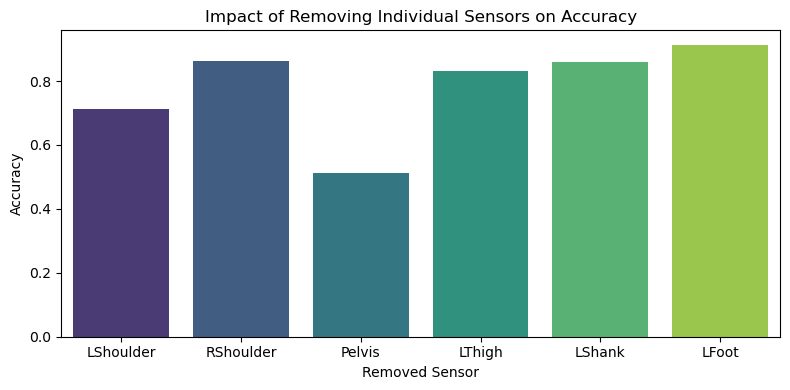

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

# -------------------
# 1. Load Data
# -------------------
squat_df = pd.read_csv("merged_data_squat.csv")
squat_df["exercise"] = "squat"
rdl_df = pd.read_csv("merged_data_rdl.csv")
rdl_df["exercise"] = "rdl"
df = pd.concat([squat_df, rdl_df], ignore_index=True)

# Features (remove frame, label, exercise)
X = df.drop(columns=["frame", "label", "exercise"]).values
y = df["label"].values  # 0 = pause, 1 = correct, 2 = incorrect

# -------------------
# 2. Sliding Window Segmentation
# -------------------
def create_sliding_windows(X, y, window_size=200, step_size=100):
    X_windows, y_windows = [], []
    for i in range(0, len(X) - window_size, step_size):
        X_windows.append(X[i:i+window_size])
        # Majority label in the window
        labels_window = y[i:i+window_size]
        y_windows.append(np.bincount(labels_window).argmax())
    return np.array(X_windows), np.array(y_windows)

window_size = 200
step_size = 100
X_seq, y_seq = create_sliding_windows(X, y, window_size, step_size)

# Reshape for CNN-LSTM (samples, timesteps, features)
n_features = X_seq.shape[2]
X_seq = X_seq.reshape((X_seq.shape[0], window_size, n_features))

# -------------------
# 3. Train-Test Split
# -------------------
X_train, X_test, y_train, y_test = train_test_split(X_seq, y_seq, test_size=0.2, random_state=42, stratify=y_seq)
y_train_cat = to_categorical(y_train, num_classes=3)
y_test_cat = to_categorical(y_test, num_classes=3)

# -------------------
# 4. CNN-LSTM Model
# -------------------
def build_cnn_lstm(input_shape):
    model = Sequential()
    model.add(Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=input_shape))
    model.add(Conv1D(filters=64, kernel_size=3, activation='relu'))
    model.add(MaxPooling1D(pool_size=2))
    model.add(Dropout(0.5))
    model.add(LSTM(200, return_sequences=False))
    model.add(Dropout(0.5))
    model.add(Dense(200, activation='relu'))
    model.add(Dense(3, activation='softmax'))  # 3 classes
    model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

model = build_cnn_lstm((window_size, n_features))
history = model.fit(X_train, y_train_cat, epochs=30, batch_size=32, validation_data=(X_test, y_test_cat), verbose=1)

# -------------------
# 5. Evaluate Model
# -------------------
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

print(classification_report(y_test, y_pred))
acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {acc:.2f}")

# -------------------
# 6. Confusion Matrix
# -------------------
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Pause", "Correct", "Incorrect"], yticklabels=["Pause", "Correct", "Incorrect"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

# -------------------
# 7. Training History Plot
# -------------------
plt.figure(figsize=(8, 4))
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# -------------------
# 8. Sensor Reduction Experiment
# -------------------
# Assume features are grouped by sensors (e.g., 6 sensors × 3 data types)
sensor_names = ["LShoulder", "RShoulder", "Pelvis", "LThigh", "LShank", "LFoot"]
sensor_feature_size = 3  # accel, gyro, quaternion per sensor

def get_sensor_indices(sensor_idx):
    start = sensor_idx * sensor_feature_size
    end = start + sensor_feature_size
    return list(range(start, end))

accuracies = []
for i in range(len(sensor_names)):
    keep_indices = [idx for s in range(len(sensor_names)) if s != i for idx in get_sensor_indices(s)]
    X_reduced = X_seq[:, :, keep_indices]
    X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reduced, y_seq, test_size=0.2, random_state=42, stratify=y_seq)
    y_train_r_cat = to_categorical(y_train_r, 3)
    y_test_r_cat = to_categorical(y_test_r, 3)
    reduced_model = build_cnn_lstm((window_size, X_reduced.shape[2]))
    reduced_model.fit(X_train_r, y_train_r_cat, epochs=10, batch_size=32, verbose=0)
    y_pred_r = np.argmax(reduced_model.predict(X_test_r), axis=1)
    acc_r = accuracy_score(y_test_r, y_pred_r)
    accuracies.append(acc_r)

plt.figure(figsize=(8, 4))
sns.barplot(x=sensor_names, y=accuracies, palette="viridis")
plt.title("Impact of Removing Individual Sensors on Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Removed Sensor")
plt.tight_layout()
plt.show()
